In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/brahmaiahchereddy/week1-output-data/user_features.csv
/kaggle/input/datasets/brahmaiahchereddy/week1-output-data/articles.csv
/kaggle/input/datasets/brahmaiahchereddy/week1-output-data/item_features.csv
/kaggle/input/datasets/brahmaiahchereddy/week1-output-data/item_vocab.json
/kaggle/input/datasets/brahmaiahchereddy/week1-output-data/transactions_train.csv
/kaggle/input/datasets/brahmaiahchereddy/week1-output-data/user_vocab.json
/kaggle/input/datasets/brahmaiahchereddy/week1-output-data/customers.csv


In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    for file in files:
        print("   ", file)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/brahmaiahchereddy
/kaggle/input/datasets/brahmaiahchereddy/week1-output-data
    user_features.csv
    articles.csv
    item_features.csv
    item_vocab.json
    transactions_train.csv
    user_vocab.json
    customers.csv


In [3]:
import pandas as pd
import json

PATH = "/kaggle/input/datasets/brahmaiahchereddy/week1-output-data/"

user_features = pd.read_csv(PATH + "user_features.csv")
item_features = pd.read_csv(PATH + "item_features.csv")

with open(PATH + "user_vocab.json", "r") as f:
    user_vocab = json.load(f)

with open(PATH + "item_vocab.json", "r") as f:
    item_vocab = json.load(f)

print(" Week 1 output loaded successfully!")

 Week 1 output loaded successfully!


In [4]:
print(user_features.shape)
print(item_features.shape)

(1362281, 9)
(104547, 7)


In [5]:
print(user_features.head())
print(item_features.head())


                                         customer_id  purchase_count  \
0  00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...              21   
1  0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...              86   
2  000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...              18   
3  00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...               2   
4  00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...              13   

   avg_spend  total_spend  days_since_last_purchase club_member_status  \
0   0.030904     0.648983                        17             ACTIVE   
1   0.030255     2.601932                        76             ACTIVE   
2   0.039154     0.704780                         7             ACTIVE   
3   0.030492     0.060983                       471             ACTIVE   
4   0.036130     0.469695                        41             ACTIVE   

  fashion_news_frequency   age        age_group  
0                   NONE  49.0      Middle Aged  
1                   NO

In [6]:
print(len(user_vocab))
print(len(item_vocab))

5
6


In [7]:
transactions = pd.read_csv(PATH + "transactions_train.csv")

In [8]:
# ── CELL 1: Run this first ──────────────────────────────
!pip install tensorflow-recommenders -q

# Week 1 output dataset
WEEK1_PATH = "/kaggle/input/datasets/brahmaiahchereddy/week1-output-data/"

# Original H&M competition data (if still needed)
DATA_PATH = "/kaggle/input/competitions/h-and-m-personalized-fashion-recommendations/"

print("Setup complete")
print("WORK_PATH:", WEEK1_PATH)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 6.6 MB/s eta 0:00:00
Setup complete
WORK_PATH: /kaggle/input/datasets/brahmaiahchereddy/week1-output-data/


In [9]:
import pandas as pd
import numpy as np
import json
import tensorflow as tf
from tensorflow.keras import layers
print('TensorFlow version :', tf.__version__)
print('GPU available      :', tf.config.list_physical_devices('GPU'))

TensorFlow version : 2.20.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [10]:
user_features = pd.read_csv(WEEK1_PATH + "user_features.csv")
item_features = pd.read_csv(WEEK1_PATH + "item_features.csv")
transactions = pd.read_csv(WEEK1_PATH + "transactions_train.csv")
customers    = pd.read_csv(WEEK1_PATH + "customers.csv")
articles     = pd.read_csv(WEEK1_PATH + "articles.csv")
with open(WEEK1_PATH + "user_vocab.json") as f:
    user_vocab = json.load(f)
with open(WEEK1_PATH + "item_vocab.json") as f:
    item_vocab = json.load(f)
print("Week 1 output loaded successfully!")

Week 1 output loaded successfully!


In [11]:
# Build final_data because Week 1 doesn't save final_data.csv
final_data = (
    transactions
    .merge(user_features, on="customer_id", how="left")
    .merge(item_features, on="article_id", how="left")
)

In [12]:
print("user_features :", user_features.shape)
print("item_features :", item_features.shape)
print("final_data    :", final_data.shape)

user_features : (1362281, 9)
item_features : (104547, 7)
final_data    : (31788324, 19)


In [13]:
# Fix any remaining duplicate columns from team member's merge
dup = [c for c in final_data.columns if c.endswith('_x') or c.endswith('_y')]
for col in dup:
    if col.endswith('_y'):
        final_data.drop(columns=[col], inplace=True)
    elif col.endswith('_x'):
        final_data.rename(columns={col: col[:-2]}, inplace=True)

In [14]:
# Fill any remaining nulls
final_data['age'].fillna(final_data['age'].median(), inplace=True)
final_data['age_group'].fillna('Adults', inplace=True)
final_data['club_member_status'].fillna('UNKNOWN', inplace=True)
final_data['fashion_news_frequency'].fillna('NONE', inplace=True)
final_data['product_type_name'].fillna('Unknown', inplace=True)
final_data['product_group_name'].fillna('Unknown', inplace=True)
final_data['garment_group_name'].fillna('Unknown', inplace=True)
final_data['colour_group_name'].fillna('Unknown', inplace=True)

# Convert article_id to string (it's numeric in H&M dataset)
final_data['article_id'] = final_data['article_id'].astype(str)
final_data['customer_id'] = final_data['customer_id'].astype(str)

print('Cleaned final_data columns:', list(final_data.columns))
print('Null counts:\n', final_data.isnull().sum()[final_data.isnull().sum() > 0])

/tmp/ipykernel_58/1894610157.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_data['age'].fillna(final_data['age'].median(), inplace=True)
/tmp/ipykernel_58/1894610157.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

Cleaned final_data columns: ['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id', 'purchase_count', 'avg_spend', 'total_spend', 'days_since_last_purchase', 'club_member_status', 'fashion_news_frequency', 'age', 'age_group', 'avg_price', 'product_type_name', 'product_group_name', 'garment_group_name', 'colour_group_name']
Null counts:
 Series([], dtype: int64)


In [15]:
# Use a sample for faster training on Kaggle (remove or increase for full run)
SAMPLE_SIZE = 500_000  # adjust based on Kaggle RAM — use None for full dataset

if SAMPLE_SIZE and len(final_data) > SAMPLE_SIZE:
    df = final_data.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
    print(f'Using sample: {len(df):,} rows')
else:
    df = final_data.copy()
    print(f'Using full dataset: {len(df):,} rows')

Using sample: 500,000 rows


In [16]:
# Train / validation split (80/20)
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
print(f'Train : {len(train_df):,} rows')
print(f'Val   : {len(val_df):,} rows')

Train : 400,000 rows
Val   : 100,000 rows


In [17]:
# Convert to TensorFlow datasets
FEATURE_COLS = [
    'customer_id', 'article_id',
    'purchase_count', 'avg_spend', 'total_spend', 'days_since_last_purchase', 'age',
    'club_member_status', 'fashion_news_frequency', 'age_group',
    'avg_price', 'product_type_name', 'product_group_name',
    'garment_group_name', 'colour_group_name'
]

In [18]:
def df_to_dataset(dataframe, shuffle=True, batch_size=1024):
    data = {col: dataframe[col].values for col in FEATURE_COLS}
    # Convert numeric columns to float32
    for col in ['purchase_count','avg_spend','total_spend','days_since_last_purchase','age','avg_price']:
        data[col] = data[col].astype('float32')
    ds = tf.data.Dataset.from_tensor_slices(data)
    if shuffle:
        ds = ds.shuffle(buffer_size=10_000)
    return ds.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)

In [19]:
def df_to_dataset(dataframe, shuffle=True, batch_size=1024):
    data = {col: dataframe[col].values for col in FEATURE_COLS}
    # Convert numeric columns to float32
    for col in ['purchase_count','avg_spend','total_spend','days_since_last_purchase','age','avg_price']:
        data[col] = data[col].astype('float32')
    ds = tf.data.Dataset.from_tensor_slices(data)
    if shuffle:
        ds = ds.shuffle(buffer_size=10_000)
    return ds.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)

In [20]:
BATCH_SIZE = 1024
train_ds = df_to_dataset(train_df, shuffle=True,  batch_size=BATCH_SIZE)
val_ds   = df_to_dataset(val_df,   shuffle=False, batch_size=BATCH_SIZE)

I0000 00:00:1782902584.619692      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782902584.622506      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [21]:
# All items dataset (needed by TFRS retrieval task)
items_df = item_features.copy()
items_df['article_id'] = items_df['article_id'].astype(str)
items_df['avg_price'] = items_df['avg_price'].astype('float32')
items_df['purchase_count'] = items_df['purchase_count'].astype('float32')
for col in ['product_type_name','product_group_name','garment_group_name','colour_group_name']:
    items_df[col] = items_df[col].fillna('Unknown')

In [22]:
items_ds = tf.data.Dataset.from_tensor_slices({
    'article_id'        : items_df['article_id'].values,
    'avg_price'         : items_df['avg_price'].values,
    'purchase_count'    : items_df['purchase_count'].values,
    'product_type_name' : items_df['product_type_name'].values,
    'product_group_name': items_df['product_group_name'].values,
    'garment_group_name': items_df['garment_group_name'].values,
    'colour_group_name' : items_df['colour_group_name'].values,
}).batch(512)

print('Datasets ready')

Datasets ready


In [23]:
# Vocabulary lists (from Day 7 vocab JSON)
customer_id_vocab  = [str(x) for x in user_vocab['customer_id']]
article_id_vocab   = [str(x) for x in item_vocab['article_id']]
club_vocab         = user_vocab['club_member_status']
news_freq_vocab    = user_vocab['fashion_news_frequency']
age_group_vocab    = user_vocab['age_group']
product_type_vocab = item_vocab['product_type_name']
product_grp_vocab  = item_vocab['product_group_name']
garment_grp_vocab  = item_vocab['garment_group_name']
colour_grp_vocab   = item_vocab['colour_group_name']

print(f'Customers : {len(customer_id_vocab):,}')
print(f'Articles  : {len(article_id_vocab):,}')

Customers : 1,362,281
Articles  : 104,547


In [24]:
EMBEDDING_DIM = 64  # size of the final embedding vector
class QueryTower(tf.keras.Model):
    def __init__(self):
        super().__init__()
        # Customer ID embedding
        self.customer_embedding = tf.keras.Sequential([
            layers.StringLookup(vocabulary=customer_id_vocab, mask_token=None),
            layers.Embedding(len(customer_id_vocab) + 1, EMBEDDING_DIM)
        ])
        # Categorical embeddings
        self.club_embedding = tf.keras.Sequential([
            layers.StringLookup(vocabulary=club_vocab, mask_token=None),
            layers.Embedding(len(club_vocab) + 1, 8)
        ])
        self.news_embedding = tf.keras.Sequential([
            layers.StringLookup(vocabulary=news_freq_vocab, mask_token=None),
            layers.Embedding(len(news_freq_vocab) + 1, 8)
        ])
        self.age_group_embedding = tf.keras.Sequential([
            layers.StringLookup(vocabulary=age_group_vocab, mask_token=None),
            layers.Embedding(len(age_group_vocab) + 1, 4)
        ])
        # Dense layers to merge everything
        self.dense = tf.keras.Sequential([
            layers.Dense(256, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.2),
            layers.Dense(128, activation='relu'),
            layers.Dense(EMBEDDING_DIM)
        ])

    def call(self, inputs):
        # Embed categorical features
        cust_emb  = self.customer_embedding(inputs['customer_id'])
        club_emb  = self.club_embedding(inputs['club_member_status'])
        news_emb  = self.news_embedding(inputs['fashion_news_frequency'])
        age_emb   = self.age_group_embedding(inputs['age_group'])
        # Numerical features — reshape to (batch, 1) then concat
        num_features = tf.stack([
            inputs['purchase_count'],
            inputs['avg_spend'],
            inputs['total_spend'],
            inputs['days_since_last_purchase'],
            inputs['age']
        ], axis=1)
        # Concatenate all features and pass through dense layers
        x = tf.concat([cust_emb, club_emb, news_emb, age_emb, num_features], axis=1)
        return self.dense(x)

print('QueryTower defined')

QueryTower defined


In [25]:
#      CANDIDATE TOWER (Item side) 
class CandidateTower(tf.keras.Model):
    def __init__(self):
        super().__init__()
        # Article ID embedding
        self.article_embedding = tf.keras.Sequential([
            layers.StringLookup(vocabulary=article_id_vocab, mask_token=None),
            layers.Embedding(len(article_id_vocab) + 1, EMBEDDING_DIM)
        ])
        # Categorical embeddings
        self.product_type_emb = tf.keras.Sequential([
            layers.StringLookup(vocabulary=product_type_vocab, mask_token=None),
            layers.Embedding(len(product_type_vocab) + 1, 16)
        ])
        self.product_grp_emb = tf.keras.Sequential([
            layers.StringLookup(vocabulary=product_grp_vocab, mask_token=None),
            layers.Embedding(len(product_grp_vocab) + 1, 8)
        ])
        self.garment_grp_emb = tf.keras.Sequential([
            layers.StringLookup(vocabulary=garment_grp_vocab, mask_token=None),
            layers.Embedding(len(garment_grp_vocab) + 1, 8)
        ])
        self.colour_grp_emb = tf.keras.Sequential([
            layers.StringLookup(vocabulary=colour_grp_vocab, mask_token=None),
            layers.Embedding(len(colour_grp_vocab) + 1, 8)
        ])
        # Dense layers
        self.dense = tf.keras.Sequential([
            layers.Dense(256, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.2),
            layers.Dense(128, activation='relu'),
            layers.Dense(EMBEDDING_DIM)
        ])

    def call(self, inputs):
        art_emb     = self.article_embedding(inputs['article_id'])
        pt_emb      = self.product_type_emb(inputs['product_type_name'])
        pg_emb      = self.product_grp_emb(inputs['product_group_name'])
        gg_emb      = self.garment_grp_emb(inputs['garment_group_name'])
        col_emb     = self.colour_grp_emb(inputs['colour_group_name'])
        num_features = tf.stack([
            inputs['avg_price'],
            inputs['purchase_count']
        ], axis=1)
        x = tf.concat([art_emb, pt_emb, pg_emb, gg_emb, col_emb, num_features], axis=1)
        return self.dense(x)

print('CandidateTower defined')

CandidateTower defined


In [26]:
#    FULL TWO-TOWER MODEL 
#   TWO-TOWER MODEL (TensorFlow/Keras) 

class TwoTowerModel(tf.keras.Model):

    def __init__(self, query_tower, candidate_tower):
        super().__init__()
        self.query_tower = query_tower
        self.candidate_tower = candidate_tower

    def call(self, features):

        user_embedding = self.query_tower(features)
        item_embedding = self.candidate_tower(features)

        return user_embedding, item_embedding

query_tower = QueryTower()
candidate_tower = CandidateTower()

model = TwoTowerModel(query_tower, candidate_tower)

print("Two-Tower model created successfully!")

Two-Tower model created successfully!


In [27]:
import tensorflow as tf

class TwoTowerModel(tf.keras.Model):

    def __init__(self, query_tower, candidate_tower):
        super().__init__()

        self.query_tower = query_tower
        self.candidate_tower = candidate_tower

        self.loss_tracker = tf.keras.metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def train_step(self, features):

        with tf.GradientTape() as tape:

            user_emb = self.query_tower(features, training=True)
            item_emb = self.candidate_tower(features, training=True)

            # L2 normalize embeddings
            user_emb = tf.math.l2_normalize(user_emb, axis=1)
            item_emb = tf.math.l2_normalize(item_emb, axis=1)

            # Similarity matrix
            logits = tf.matmul(user_emb, item_emb, transpose_b=True)

            # Positive pair = diagonal
            labels = tf.range(tf.shape(logits)[0])

            loss = tf.keras.losses.sparse_categorical_crossentropy(
                labels,
                logits,
                from_logits=True
            )

            loss = tf.reduce_mean(loss)

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_tracker.update_state(loss)

        return {"loss": self.loss_tracker.result()}

In [28]:
query_tower = QueryTower()
candidate_tower = CandidateTower()

model = TwoTowerModel(
    query_tower,
    candidate_tower
)

In [29]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    )
)

***Training***

In [30]:
# EarlyStopping is a callback that automatically stops training if the model stops improving
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="loss",
    patience=3,
    restore_best_weights=True
)
# This callback reduces the learning rate automatically when training stops improving
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="loss",
    factor=0.5,
    patience=2,
    verbose=1
)
history = model.fit(
    train_ds,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

print("Training completed successfully!")

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 62ms/step - loss: 6.1691 - learning_rate: 0.0010
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - loss: 6.0746 - learning_rate: 0.0010
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - loss: 6.0477 - learning_rate: 0.0010
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - loss: 6.0369 - learning_rate: 0.0010
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - loss: 6.0290 - learning_rate: 0.0010
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - loss: 6.0216 - learning_rate: 0.0010
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - loss: 6.0171 - learning_rate: 0.0010
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - loss: 6.0148 - learning_rate: 0.0010
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - loss: 6.0123 - learning_rate: 0.0010
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - loss: 6.0107 - learning_rate: 0.0010
Training completed successfully!


In [31]:
# Generate User Embeddings
user_embeddings = {}

for batch in train_ds:
    emb = query_tower(batch)

    customer_ids = batch["customer_id"].numpy()

    for cid, vec in zip(customer_ids, emb.numpy()):
        user_embeddings[cid.decode("utf-8")] = vec

print("Total users:", len(user_embeddings))

Total users: 272034


In [32]:
# Generate Item Embeddings
item_embeddings = {}

for batch in train_ds:
    emb = candidate_tower(batch)

    article_ids = batch["article_id"].numpy()

    for aid, vec in zip(article_ids, emb.numpy()):
        item_embeddings[aid.decode("utf-8")] = vec

print("Total items:", len(item_embeddings))

Total items: 57318


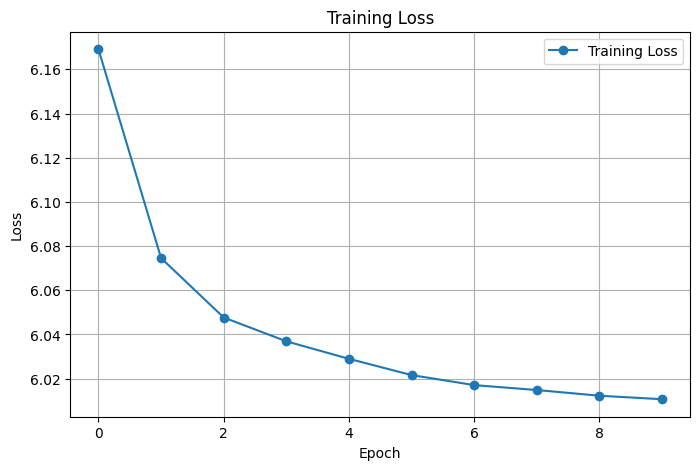

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], marker="o", label="Training Loss")

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.show()

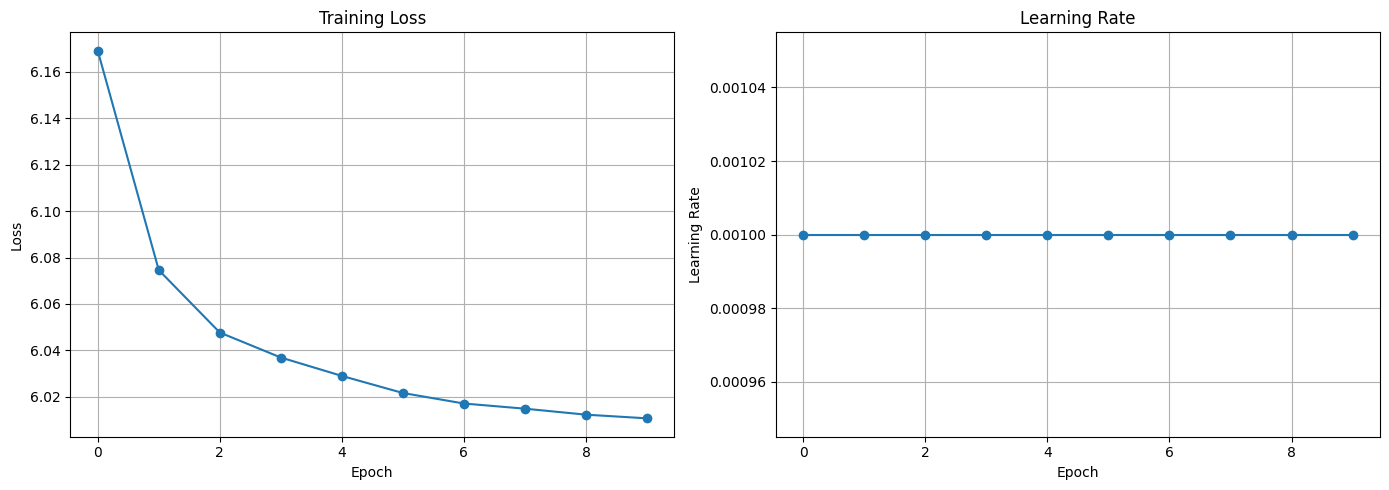

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Loss
axes[0].plot(history.history["loss"], marker="o")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
# Learning Rate
axes[1].plot(history.history["learning_rate"], marker="o")
axes[1].set_title("Learning Rate")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Learning Rate")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Generate Item Embeddings

item_embeddings = {}

unique_items = final_data.drop_duplicates("article_id")

for _, row in unique_items.iterrows():

    features = {
        "article_id": tf.constant([str(row["article_id"])]),
        "product_type_name": tf.constant([str(row["product_type_name"])]),
        "product_group_name": tf.constant([str(row["product_group_name"])]),
        "garment_group_name": tf.constant([str(row["garment_group_name"])]),
        "colour_group_name": tf.constant([str(row["colour_group_name"])]),
        "avg_price": tf.constant([float(row["avg_price"])], dtype=tf.float32),
        "purchase_count": tf.constant([float(row["purchase_count"])], dtype=tf.float32)
    }

    embedding = candidate_tower(features).numpy()[0]

    item_embeddings[str(row["article_id"])] = embedding

print("Total Item Embeddings:", len(item_embeddings))

In [ ]:
# Generate User Embeddings

import numpy as np

user_embeddings = {}

# Use only unique users
unique_users = final_data.drop_duplicates("customer_id")

for _, row in unique_users.iterrows():

    features = {
        "customer_id": tf.constant([str(row["customer_id"])]),
        "club_member_status": tf.constant([str(row["club_member_status"])]),
        "fashion_news_frequency": tf.constant([str(row["fashion_news_frequency"])]),
        "age_group": tf.constant([str(row["age_group"])]),
        "purchase_count": tf.constant([float(row["purchase_count"])], dtype=tf.float32),
        "avg_spend": tf.constant([float(row["avg_spend"])], dtype=tf.float32),
        "total_spend": tf.constant([float(row["total_spend"])], dtype=tf.float32),
        "days_since_last_purchase": tf.constant([float(row["days_since_last_purchase"])], dtype=tf.float32),
        "age": tf.constant([float(row["age"])], dtype=tf.float32)
    }

    embedding = query_tower(features).numpy()[0]

    user_embeddings[str(row["customer_id"])] = embedding

print("Total User Embeddings:", len(user_embeddings))

In [36]:
import pickle

with open("user_embeddings.pkl", "wb") as f:
    pickle.dump(user_embeddings, f)

with open("item_embeddings.pkl", "wb") as f:
    pickle.dump(item_embeddings, f)

print("Embeddings saved successfully!")

Embeddings saved successfully!


In [37]:
query_tower.save("query_tower.keras")
candidate_tower.save("candidate_tower.keras")

print("Models saved successfully!")

Models saved successfully!
